Idea: Construct a minimal energy system model to depict simple first material flows. Model taken from one-node example.

In [35]:
import warnings

warnings.filterwarnings(
    "ignore"
)  # For better visibility, warnings are turned off in this notebook

# import packages
import fine as fn
from getData import getData
from pathlib import Path


cwd = Path.cwd()
data = getData()

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Construct Model

In [ ]:
# define basic parameters
locations = {"GermanyRegion"}
commodityUnitDict = {"electricity": r"GW$_{el}$", "hydrogen": r"GW$_{H_{2},LHV}$"}
commodities = {"electricity", "hydrogen"}
numberOfTimeSteps = 8760
hoursPerTimeStep = 1

# initiate model suite 
esM = fn.EnergySystemModel(
    locations=locations,
    commodities=commodities,
    numberOfTimeSteps=8760,
    commodityUnitsDict=commodityUnitDict,
    hoursPerTimeStep=1,
    costUnit="1e9 Euro",
    lengthUnit="km",
    verboseLogLevel=0,
)

esM.resourceLimit = {
    'cobalt': 10,
    'lithium': 10
}

# Electricity Source: Wind onshore 
esM.add(
    fn.Source(
        esM=esM,
        name="Wind (onshore)",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=data["Wind (onshore), operationRateMax"],
        capacityMax=data["Wind (onshore), capacityMax"],
        investPerCapacity=1.1,
        opexPerCapacity=1.1 * 0.02,
        interestRate=0.08,
        economicLifetime=20,
        #MaterialIntensity = {"cobalt": 5}
    )
)

data["Wind (onshore), operationRateMax"].sum()

# Conversion: Hydrogen to Electricity 
esM.add(
    fn.Conversion(
        esM=esM,
        name="New CCGT plants (hydrogen)",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={"electricity": 1, "hydrogen": -1 / 0.6},
        hasCapacityVariable=True,
        investPerCapacity=0.7,
        opexPerCapacity=0.021,
        interestRate=0.08,
        economicLifetime=33,
        MaterialIntensity = {"cobalt": 5}
    )
)

# Conversion: Electricity to Hydrogen
esM.add(
    fn.Conversion(
        esM=esM,
        name="Electroylzers",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={"electricity": -1, "hydrogen": 0.7},
        hasCapacityVariable=True,
        investPerCapacity=0.5,
        opexPerCapacity=0.5 * 0.025,
        interestRate=0.08,
        economicLifetime=10,
        MaterialIntensity = {"cobalt": 5}
    )
)

# Electricity Storage 
esM.add(
    fn.Storage(
        esM=esM,
        name="Li-ion batteries",
        commodity="electricity",
        hasCapacityVariable=True,
        chargeEfficiency=0.95,
        cyclicLifetime=10000,
        dischargeEfficiency=0.95,
        selfDischarge=1 - (1 - 0.03) ** (1 / (30 * 24)),
        chargeRate=1,
        dischargeRate=1,
        doPreciseTsaModeling=False,
        investPerCapacity=0.151,
        opexPerCapacity=0.002,
        interestRate=0.08,
        economicLifetime=22,
        MaterialIntensity = {"lithium": 5}
    )
)

# Hydrogen Storage 
esM.add(
    fn.Storage(
        esM=esM,
        name="Salt caverns (hydrogen)",
        commodity="hydrogen",
        hasCapacityVariable=True,
        capacityVariableDomain="continuous",
        capacityPerPlantUnit=133,
        chargeRate=1 / 470.37,
        dischargeRate=1 / 470.37,
        sharedPotentialID="Existing salt caverns",
        stateOfChargeMin=0.33,
        stateOfChargeMax=1,
        capacityMax=data["Salt caverns (hydrogen), capacityMax"],
        investPerCapacity=0.00011,
        opexPerCapacity=0.00057,
        interestRate=0.08,
        economicLifetime=30,
        MaterialIntensity = {"cobalt": 5}
    )
)

# Electricity demand
esM.add(
    fn.Sink(
        esM=esM,
        name="Electricity demand",
        commodity="electricity",
        hasCapacityVariable=False,
        operationRateFix=data["Electricity demand, operationRateFix"],
    )
)

# Hydrogen demand
FCEV_penetration = 0.5
esM.add(
    fn.Sink(
        esM=esM,
        name="Hydrogen demand",
        commodity="hydrogen",
        hasCapacityVariable=False,
        operationRateFix=data["Hydrogen demand, operationRateFix"] * FCEV_penetration,
    )
)

## Optimize

In [41]:
# aggregate data 
esM.aggregateTemporally(numberOfTypicalPeriods=30)


Clustering time series data with 30 typical periods and 24 time steps per period 
further clustered to 12 segments per period...
		(3.6620 sec)



In [42]:
# optimize model
esM.optimize(timeSeriesAggregation=True, solver="glpk") 

Time series aggregation specifications:
Number of typical periods:30, number of time steps per period:24, number of segments per period:12

Declaring sets, variables and constraints for SourceSinkModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 
		(0.1631 sec)

Declaring sets, variables and constraints for ConversionModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 
		(0.0585 sec)

Declaring sets, variables and constraints for StorageModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 
ERROR: Rule failed when generating expression for Constraint
ConstrSOCMaxSimple_stor with index ('GermanyRegion', 'Li-ion batteries', 0,
0): ValueError: Constraint 'ConstrSOCMaxSimple_stor[GermanyRegion,Li-ion
batteries,0,0]': rule returned None.

    Constraint rules must return either a valid expression, a 2- or 3-member
    tuple, or one of Constraint.Skip, Constraint.Feasible, or
    Constraint.Infeasible.  The most commo

ValueError: Constraint 'ConstrSOCMaxSimple_stor[GermanyRegion,Li-ion batteries,0,0]': rule returned None.

Constraint rules must return either a valid expression, a 2- or 3-member
tuple, or one of Constraint.Skip, Constraint.Feasible, or
Constraint.Infeasible.  The most common cause of this error is
forgetting to include the "return" statement at the end of your rule.


## Show Results 

In [14]:
# optimization summary
esM.getOptimizationSummary("StorageModel", outputLevel=2) 

GermanyRegion
Component               Property           Unit                                
Li-ion batteries        NPVcontribution    [1e9 Euro]                  3.744658
                        TAC                [1e9 Euro/a]                3.744658
                        capacity           [GW$_{el}$*h]             222.858625
                        capexCap           [1e9 Euro/a]                3.298941
                        commissioning      [GW$_{el}$*h]             222.858625
                        invest             [1e9 Euro]                 33.651652
                        operationCharge    [GW$_{el}$*h/a]          9780.143481
                                           [GW$_{el}$*h]            9780.143481
                        operationDischarge [GW$_{el}$*h/a]          8789.314282
                                           [GW$_{el}$*h]            8789.314282
                        opexCap            [1e9 Euro/a]                0.445717
Salt caverns (hydrogen) NPVcontribution    [1e9 Euro]                   0.00116
                        TAC                [1e9 Euro/a]                 0.00116
                        capacity           [GW$_{H_{2},LHV}$*h]             2.0
                        capexCap           [1e9 Euro/a]                 0.00002
                        commissioning      [GW$_{H_{2},LHV}$*h]             2.0
                        invest             [1e9 Euro]                   0.00022
                        operationCharge    [GW$_{H_{2},LHV}$*h/a]     18.001789
                                           [GW$_{H_{2},LHV}$*h]       18.001789
                        operationDischarge [GW$_{H_{2},LHV}$*h/a]     18.001789
                                           [GW$_{H_{2},LHV}$*h]       18.001789
                        opexCap            [1e9 Euro/a]                 0.00114

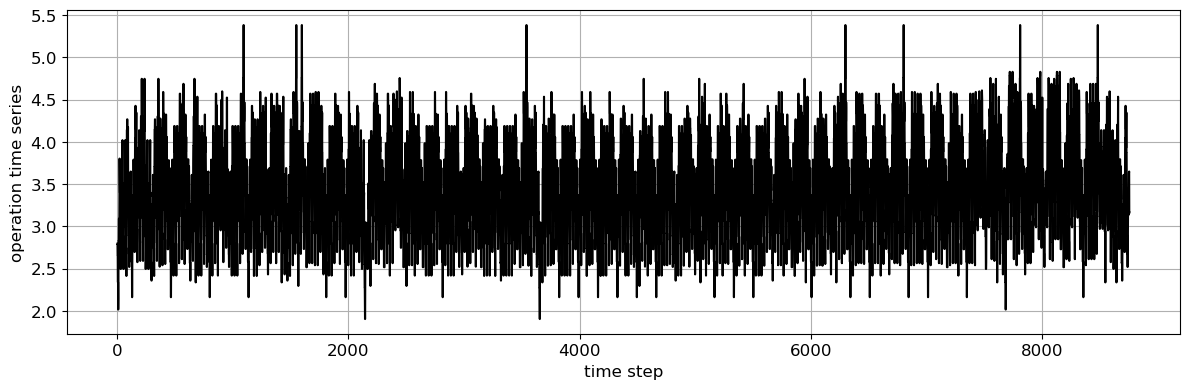

In [17]:
# operation time series
fig, ax = fn.plotOperation(esM, "Electricity demand", "GermanyRegion")